<!-- **FNN using DeepXDE module** -->

In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow.compat.v1"

import deepxde as dde


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.



Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d


<!-- Data loading -->

In [3]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'r')

data_I_noisy_2 = np.array(np.array(datastore["I_large"]))

data_c_2 = np.array(np.array(datastore["c_large"]))
data_h_2 = np.array(np.array(datastore["h_large"]))
keys = list(datastore.keys())

data_p_3 = np.array(np.array(datastore["parameters_large: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts"]))

t = np.linspace(0, 1, 601).reshape(601, 1)

data_f0_2 = data_p_3[:, 4] * 1e3
data_ts_2 = data_p_3[:, 8]
data_h0_2 = data_p_3[:, 7] * 1e6
datastore.close()

<!-- Train-test split -->

In [4]:
train_label_2, test_label_2 = train_test_split(range(len(data_I_noisy_2)), test_size=0.5, random_state=42)

data_i_noisy_2_train = data_I_noisy_2[train_label_2]
data_i_noisy_2_test = data_I_noisy_2[test_label_2]

data_c_2_train = data_c_2[train_label_2]
data_c_2_test = data_c_2[test_label_2]

data_h_2_train = data_h_2[train_label_2]
data_h_2_test = data_h_2[test_label_2]

data_f0_2_train = data_f0_2[train_label_2]
data_f0_2_test = data_f0_2[test_label_2]

data_ts_2_train = data_ts_2[train_label_2]
data_ts_2_test = data_ts_2[test_label_2]

data_h0_2_train = data_h0_2[train_label_2]
data_h0_2_test = data_h0_2[test_label_2]

del datastore, data_I_noisy_2, data_c_2, data_h_2, data_p_3, data_f0_2, data_ts_2, data_h0_2

In [5]:
pca_i_2 = PCA(n_components=4, svd_solver='full')
pca_i_2.fit(data_i_noisy_2_train)

data_i_noisy_2_train_pca = pca_i_2.transform(data_i_noisy_2_train)
data_i_noisy_2_train_pca_reconstructed = pca_i_2.inverse_transform(data_i_noisy_2_train_pca)

# Calculate mean squared error for data_i_2_noisy_train
mse_i_2_noisy_train = np.mean((data_i_noisy_2_train - data_i_noisy_2_train_pca_reconstructed) ** 2)
print(f"Mean Squared Error for data_i_2_noisy_train after PCA reconstruction: {mse_i_2_noisy_train}")

data_i_2_noisy_test_pca = pca_i_2.transform(data_i_noisy_2_test)
data_i_2_noisy_test_pca_reconstructed = pca_i_2.inverse_transform(data_i_2_noisy_test_pca)

# Calculate mean squared error for data_i_2_noisy_test
mse_i_2_noisy_test = np.mean((data_i_noisy_2_test - data_i_2_noisy_test_pca_reconstructed) ** 2)
print(f"Mean Squared Error for data_i_2_noisy_test after PCA reconstruction: {mse_i_2_noisy_test}")

n_components_i = pca_i_2.n_components_

del mse_i_2_noisy_train, mse_i_2_noisy_test, data_i_2_noisy_test_pca_reconstructed

Mean Squared Error for data_i_2_noisy_train after PCA reconstruction: 0.00013905396827403025
Mean Squared Error for data_i_2_noisy_test after PCA reconstruction: 0.00013875748698027063


In [6]:
pca_c_2 = PCA(n_components=4, svd_solver='full')
pca_c_2.fit(data_c_2_train)

data_c_2_train_pca = pca_c_2.transform(data_c_2_train)
data_c_2_train_reconstructed = pca_c_2.inverse_transform(data_c_2_train_pca)

# Calculate mean squared error for data_c_3_train
mse_train_2 = np.mean((data_c_2_train - data_c_2_train_reconstructed)**2)
print(f"Mean Squared Error for data_c_2_train: {mse_train_2}")

# Calculate mean squared error for data_c_3_test
data_c_2_test_pca = pca_c_2.transform(data_c_2_test)
data_c_2_test_reconstructed = pca_c_2.inverse_transform(data_c_2_test_pca)
mse_test_2 = np.mean((data_c_2_test - data_c_2_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_3_test: {mse_test_2}")

n_components_c = pca_c_2.n_components_

del mse_train_2, mse_test_2, data_c_2_test_reconstructed

Mean Squared Error for data_c_2_train: 8.029733370217658e-06
Mean Squared Error for data_c_3_test: 7.726001093980463e-06


In [7]:
pca_h_2 = PCA(n_components=4, svd_solver='full')
pca_h_2.fit(data_h_2_train)

data_h_2_train_pca = pca_h_2.transform(data_h_2_train)
data_h_2_train_reconstructed = pca_h_2.inverse_transform(data_h_2_train_pca)

# Calculate mean squared error for data_h_3_train
mse_train_2 = np.mean((data_h_2_train - data_h_2_train_reconstructed)**2)
print(f"Mean Squared Error for data_h_2_train: {mse_train_2}")

# Calculate mean squared error for data_h_3_test
data_h_2_test_pca = pca_h_2.transform(data_h_2_test)
data_h_2_test_reconstructed = pca_h_2.inverse_transform(data_h_2_test_pca)
mse_test_2 = np.mean((data_h_2_test - data_h_2_test_reconstructed)**2)
print(f"Mean Squared Error for data_h_3_test: {mse_test_2}")

n_components_h = pca_h_2.n_components_

del mse_train_2, mse_test_2, data_h_2_test_reconstructed

Mean Squared Error for data_h_2_train: 1.7424512065524674e-06
Mean Squared Error for data_h_3_test: 1.7288164184695389e-06


In [8]:
enhahnced_data_i_train_noisy = np.hstack((data_i_noisy_2_train_pca, data_f0_2_train.reshape((-1,1)), data_ts_2_train.reshape((-1,1)), data_h0_2_train.reshape((-1,1))))
enhahnced_data_i_test_noisy = np.hstack((data_i_2_noisy_test_pca, data_f0_2_test.reshape((-1,1)), data_ts_2_test.reshape((-1,1)), data_h0_2_test.reshape((-1,1))))

In [9]:
X_train_noisy_3 = enhahnced_data_i_train_noisy.astype(np.float32)
y_train_c_3 = data_c_2_train_pca.astype(np.float32)

X_test_noisy_3 = enhahnced_data_i_test_noisy.astype(np.float32)
y_test_c_3 = data_c_2_test_pca.astype(np.float32)
data_c_noisy_3 = dde.data.dataset.DataSet(
    X_train=X_train_noisy_3, y_train=y_train_c_3, X_test=X_test_noisy_3, y_test=y_test_c_3
)


net_c_noisy_3 = dde.nn.fnn.FNN(
    [n_components_i+3, 300, 300, 300, n_components_c],
    "relu",
    "Glorot normal",
)

model_c_noisy_3 = dde.Model(data_c_noisy_3, net_c_noisy_3)
model_c_noisy_3.compile("adam", lr=0.001, loss="mse", metrics=["l2 relative error"])
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca_enhanced_noisy3-1000.ckpt'
model_c_noisy_3.restore(path)
# losshistory_c_noisy_3, train_state_c_noisy_3 = model_c_noisy_3.train(iterations=1000, display_every=100)

Compiling model...
Building feed-forward neural network...
'build' took 0.070411 s


'compile' took 0.295960 s

INFO:tensorflow:Restoring parameters from C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca_enhanced_noisy3-1000.ckpt


In [10]:
y_train_h_3 = data_h_2_train_pca.astype(np.float32)
y_test_h_3 = data_h_2_test_pca.astype(np.float32)

data_h_noisy_3 = dde.data.dataset.DataSet(
    X_train=X_train_noisy_3, y_train=y_train_h_3, X_test=X_test_noisy_3, y_test=y_test_h_3
)

net_h_noisy_3 = dde.nn.fnn.FNN(
    [n_components_i+3, 300, 300, 300, n_components_h],
    "relu",
    "Glorot normal",
)

model_h_noisy_3 = dde.Model(data_h_noisy_3, net_h_noisy_3)
model_h_noisy_3.compile("adam", lr=0.001, loss='mse', metrics=["l2 relative error"])
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca_enhanced_noisy3-1000.ckpt'
model_h_noisy_3.restore(path)
# losshistory_h_noisy_3, train_state_h_noisy_3 = model_h_noisy_3.train(iterations=1000, display_every=100)

Compiling model...
Building feed-forward neural network...
'build' took 0.073195 s

'compile' took 0.218025 s

INFO:tensorflow:Restoring parameters from C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca_enhanced_noisy3-1000.ckpt


In [11]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca_enhanced_noisy3"
# model_c_noisy_3.save(path)

In [12]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca_enhanced_noisy3"
# model_h_noisy_3.save(path)

Average Relative RMSE for model_c on noisy data with 3 noise levels: 0.08095857292573196
Average Relative RMSE for model_h on noisy data with 3 noise levels: 0.030740278947275414


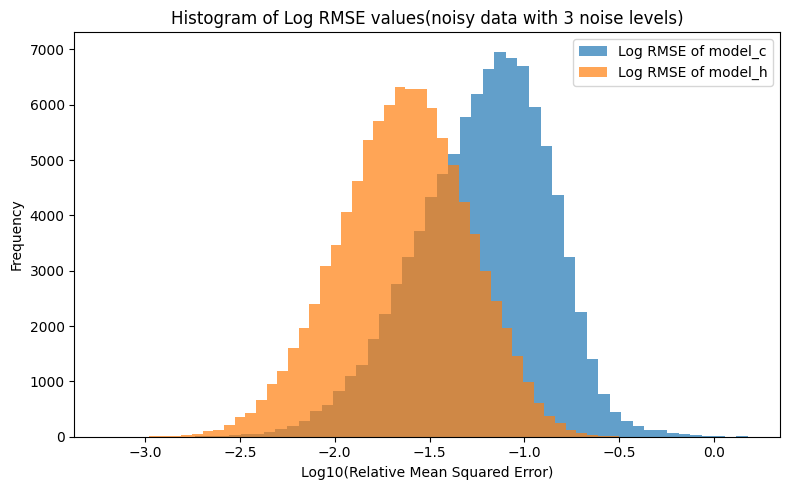

In [41]:
predictions_c_noisy_3 = pca_c_2.inverse_transform(model_c_noisy_3.predict(X_test_noisy_3))
predictions_h_noisy_3 = pca_h_2.inverse_transform(model_h_noisy_3.predict(X_test_noisy_3))


# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_noisy_2 = np.sqrt(np.sum((predictions_c_noisy_3 - data_c_2_test) ** 2, axis=1) / np.sum((data_c_2_test ** 2), axis=1))  # Averaging across time points
rrmse_h_noisy_2 = np.sqrt(np.sum((predictions_h_noisy_3 - data_h_2_test) ** 2, axis=1) / np.sum((data_h_2_test ** 2), axis=1))  # Averaging across time points

datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'a')
with datastore as hf:
    if "predictions_c_enhanced_pca" in hf:
        del hf["predictions_c_enhanced_pca"]
    if "predictions_h_enhanced_pca" in hf:
        del hf["predictions_h_enhanced_pca"]
    hf.create_dataset("predictions_c_enhanced_pca", data=predictions_c_noisy_3, compression="gzip")
    hf.create_dataset("predictions_h_enhanced_pca", data=predictions_h_noisy_3, compression="gzip")
    
datastore.close()

print(f"Average Relative RMSE for model_c on noisy data with 3 noise levels: {np.mean(rrmse_c_noisy_2)}")
print(f"Average Relative RMSE for model_h on noisy data with 3 noise levels: {np.mean(rrmse_h_noisy_2)}")

# Log-scale histogram
plt.figure(figsize=(8, 5))
plt.hist(np.log10(rrmse_c_noisy_2), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_noisy_2), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values(noisy data with 3 noise levels)')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [n_components_i+3, 300, 300, 300, n_components_c]

branch_params = compute_parameters(branch_layers)
total_params = branch_params
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 184204


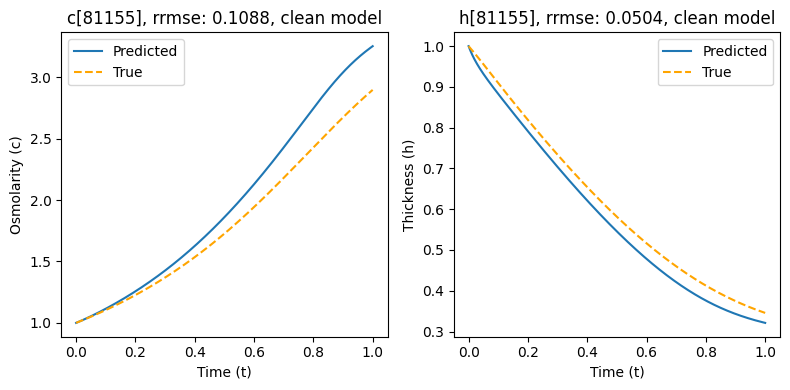

True PCA c: [ 9.41643996 -2.54786669  0.65658612 -0.23279545]
Predicted PCA c (clean): [[14.451464   -3.1022224   0.4843743  -0.29100814]]
True PCA h: [ 0.74751192  1.54682826 -0.08028647  0.10406577]
Predicted PCA h (clean): [[-0.02709689  1.3989887  -0.08418714  0.01057267]]


In [16]:
n = np.random.choice(len(data_i_noisy_2_test))  # Randomly select an index for testing
true_pca_c = data_c_2_test_pca[n]
pred_pca_c_3 = model_c_noisy_3.predict(enhahnced_data_i_test_noisy[n].reshape(1, -1))
pred_c_3 = pca_c_2.inverse_transform(pred_pca_c_3)


true_pca_h = data_h_2_test_pca[n]
pred_pca_h_3 = model_h_noisy_3.predict(enhahnced_data_i_test_noisy[n].reshape(1, -1))
pred_h_3 = pca_h_2.inverse_transform(pred_pca_h_3)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(t, pred_c_3.T)
axs[0].plot(t, data_c_2_test[n].reshape((-1,1)), linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], rrmse: {rrmse_c_noisy_2[n]:.4f}, clean model')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(t, pred_h_3.T)
axs[1].plot(t, data_h_2_test[n].reshape((-1,1)), linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], rrmse: {rrmse_h_noisy_2[n]:.4f}, clean model')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])
plt.tight_layout()
plt.show()

print(f"True PCA c: {true_pca_c}")
print(f"Predicted PCA c (clean): {pred_pca_c_3}")
print(f"True PCA h: {true_pca_h}")
print(f"Predicted PCA h (clean): {pred_pca_h_3}")


In [36]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/PDE_1d_glob_new_center_filtered.jld2", 'r')
data_I_glob = np.array(np.array(datastore_glob["filtered_data_I"]))

data_c_glob = np.array(np.array(datastore_glob["filtered_data_c"]))
data_h_glob = np.array(np.array(datastore_glob["filtered_data_h"]))

data_p_glob = np.array(np.array(datastore_glob["filtered_para"]))
data_ts_glob = data_p_glob[:,0].reshape(-1, 1)
data_h0_glob = data_p_glob[:,1].reshape(-1, 1)
data_f0_glob = data_p_glob[:,2].reshape(-1, 1)

datastore_glob.close()


Average Relative RMSE for model_c on global data(clean model): 0.20755282604848116
Average Relative RMSE for model_h on global data(clean model): 0.39445621063934644


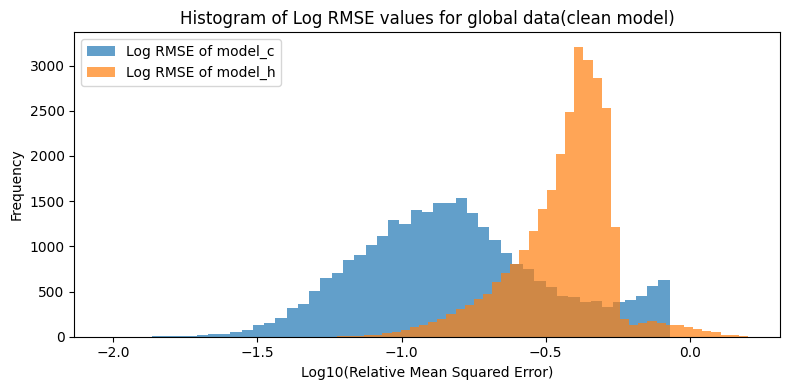

In [38]:
# Prepare the test data
X_test_glob = data_I_glob.astype(np.float32)
X_test_glob_pca_clean = pca_i_2.transform(X_test_glob)
X_test_glob_pca_clean = np.hstack((X_test_glob_pca_clean, data_f0_glob, data_ts_glob, data_h0_glob)).astype(np.float32)
X_test_glob_pca_noisy = pca_i_2.transform(X_test_glob)
X_test_glob_pca_noisy = np.hstack((X_test_glob_pca_noisy, data_f0_glob, data_ts_glob, data_h0_glob)).astype(np.float32)

y_test_c_glob = data_c_glob.astype(np.float32)
y_test_c_glob_pca = pca_c_2.transform(y_test_c_glob)
y_test_h_glob = data_h_glob.astype(np.float32)
y_test_h_glob_pca = pca_h_2.transform(y_test_h_glob)

# Use trained models to make predictions
predictions_c_glob = pca_c_2.inverse_transform(model_c_noisy_3.predict(X_test_glob_pca_clean))
predictions_h_glob = pca_h_2.inverse_transform(model_h_noisy_3.predict(X_test_glob_pca_clean))

datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'a')
with datastore as hf:
    if "predictions_c_enhanced_pca_glob" in hf:
        del hf["predictions_c_enhanced_pca_glob"]
    if "predictions_h_enhanced_pca_glob" in hf:
        del hf["predictions_h_enhanced_pca_glob"]
    hf.create_dataset("predictions_c_enhanced_pca_glob", data=predictions_c_glob, compression="gzip")
    hf.create_dataset("predictions_h_enhanced_pca_glob", data=predictions_h_glob, compression="gzip")
    
datastore.close()

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_glob_clean = np.sqrt(np.sum((predictions_c_glob - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_glob_clean = np.sqrt(np.sum((predictions_h_glob - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

print(f"Average Relative RMSE for model_c on global data(clean model): {np.mean(rrmse_c_glob_clean)}")
print(f"Average Relative RMSE for model_h on global data(clean model): {np.mean(rrmse_h_glob_clean)}")

# Log-scale histogram
plt.figure(figsize=(8, 4))
plt.hist(np.log10(rrmse_c_glob_clean), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_glob_clean), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data(clean model)')
plt.legend()
plt.tight_layout()
plt.show()

<!-- # Testing the model on experimental data -->

In [19]:
exprimental_data_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional.txt"
exprimental_data_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional_2.h5"
exprimental_data_nondimensional_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5"

In [20]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t = h5f['t'][:]
    I = h5f['I'][:]
    p = h5f['p'][:]
    
I_scaled = np.array([row / row[0] for row in I], dtype=object)


In [21]:
def scale_time_arrays(t):
    """
    Linearly scale each time array so that:
      - the first value becomes 0
      - the value equal to ts becomes 1

    Parameters:
    - t: list or array of 1D numpy arrays (ragged)
    - ts_array: 1D array of float, ts for each instance

    Returns:
    - t_scaled: list of scaled time arrays with same structure
    """
    t_scaled = []

    for i in range(len(t)):
        t_i = t[i]
        t0 = t_i[0]
        t_end = t_i[-1]  # Assuming ts is the last value in the array

        t_scaled_i = (t_i - t0) / (t_end - t0)
        t_scaled.append(t_scaled_i)

    return np.array(t_scaled, dtype=object)


In [22]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t_group = h5f['t']
    # Structured array access for 'ts'
    ts_array = h5f['p']['ts']
    id_array = h5f['p']['id']

t_scaled = scale_time_arrays(t)


In [23]:
from scipy.interpolate import PchipInterpolator

# Interpolate each row of t_scaled and I_scaled to length 601
n_points = 601
t_uniform = np.linspace(0, 1, n_points)

t_scaled_interp = []
I_scaled_interp = []

for t_row, I_row in zip(t_scaled, I_scaled):
    # Interpolators
    t_interp = t_uniform  # target x-axis
    I_interp_func = PchipInterpolator(t_row, I_row)
    I_interp = I_interp_func(t_interp)
    t_scaled_interp.append(t_interp)
    I_scaled_interp.append(I_interp)

t_scaled_interp = np.array(t_scaled_interp)
I_scaled_interp = np.array(I_scaled_interp)

In [24]:
datastore = h5py.File(exprimental_data_nondimensional_path_h5, 'r')
print(list(datastore.keys()))
data_I_calculated = np.array(datastore["calculated_I"])
data_h_calculated = np.array(datastore["calculated_h"])
data_f_calculated = np.array(datastore["calculated_f"])

data_c_caluculated = np.array(datastore["calculated_c"])
data_p_experimental_nondimensional = np.array(datastore["nondimensional_p"])

J_e_exp = data_p_experimental_nondimensional[:, 0]
b_1_exp = data_p_experimental_nondimensional[:, 1]
b_2_exp = data_p_experimental_nondimensional[:, 2]
h_e_exp = data_p_experimental_nondimensional[:, 3]
f0_data_exp = data_p_experimental_nondimensional[:, 4] * 1e3
Pc_exp = data_p_experimental_nondimensional[:, 5]
phi_exp = data_p_experimental_nondimensional[:, 6]
h0_data_exp = data_p_experimental_nondimensional[:, 7] * 1e6
ts_data_exp = data_p_experimental_nondimensional[:, 8]
residual_exp = data_p_experimental_nondimensional[:, 9] 

datastore.close()  # Close the read-only handle

['calculated_I', 'calculated_c', 'calculated_f', 'calculated_h', 'nondimensional_p', 'predictions_c_ffn_calculated', 'predictions_h_ffn_calculated']


In [25]:
# print(np.max(f0_exp), np.min(f0_exp), np.max(ts_exp), np.min(ts_data_exp), np.max(h0_data_exp), np.min(h0_data_exp))
# print(np.max(f0_data), np.min(f0_data), np.max(ts_data), np.min(ts_data), np.max(h0_data), np.min(h0_data))

Experimental RMSE for model_c_clean: 0.2079411010064495
Experimental RMSE for model_h_clean: 0.06791930129886678


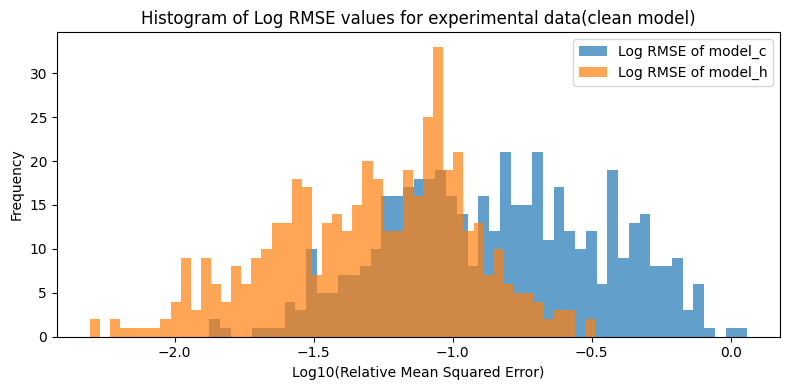

In [39]:
# Prepare the test data
X_test_expr = I_scaled_interp.astype(np.float32)
y_test_c_calculated = data_c_caluculated.astype(np.float32)
y_test_h_calculated = data_h_calculated.astype(np.float32)

X_test_calculated_pca = pca_i_2.transform(X_test_expr)
X_test_calculated_pca = np.hstack((X_test_calculated_pca, f0_data_exp[:,np.newaxis], ts_data_exp[:,np.newaxis], h0_data_exp[:,np.newaxis])).astype(np.float32)

y_test_c_calculated_pca = pca_c_2.transform(y_test_c_calculated)
y_test_h_calculated_pca = pca_h_2.transform(y_test_h_calculated)


# Use trained models to make predictions
predictions_c_calculated_pca = model_c_noisy_3.predict(X_test_calculated_pca)
predictions_h_calculated_pca = model_h_noisy_3.predict(X_test_calculated_pca)

predictions_c_calculated = pca_c_2.inverse_transform(predictions_c_calculated_pca)
predictions_h_calculated = pca_h_2.inverse_transform(predictions_h_calculated_pca)

datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'a')
with datastore as hf:
    if "predictions_c_enhanced_pca_experimental" in hf:
        del hf["predictions_c_enhanced_pca_experimental"]
    if "predictions_h_enhanced_pca_experimental" in hf:
        del hf["predictions_h_enhanced_pca_experimental"]
    hf.create_dataset("predictions_c_enhanced_pca_experimental", data=predictions_c_calculated, compression="gzip")
    hf.create_dataset("predictions_h_enhanced_pca_experimental", data=predictions_h_calculated, compression="gzip")

datastore.close()

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_calculated = np.sqrt(np.mean((predictions_c_calculated - y_test_c_calculated) ** 2, axis=1) / np.mean((y_test_c_calculated ** 2), axis=1))
rrmse_h_calculated = np.sqrt(np.mean((predictions_h_calculated - y_test_h_calculated) ** 2, axis=1) / np.mean((y_test_h_calculated ** 2), axis=1))

print("Experimental RMSE for model_c_clean:", np.mean(rrmse_c_calculated))
print("Experimental RMSE for model_h_clean:", np.mean(rrmse_h_calculated))

# Log-scale histogram
plt.figure(figsize=(8, 4))
plt.hist(np.log10(rrmse_c_calculated), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_calculated), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for experimental data(clean model)')
plt.legend()
plt.tight_layout()
plt.show()

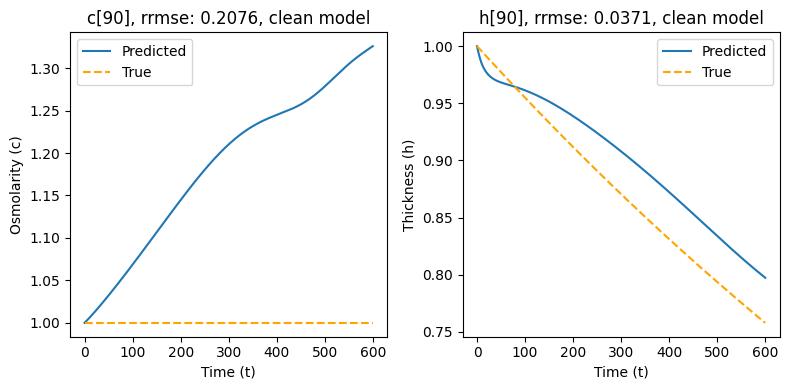

True PCA c: [-14.69017541   0.84012398  -0.26509215   0.0409083 ]
Predicted PCA c (clean): [[-9.909948   -0.7386301   0.41467807 -0.25622496]]
True PCA h: [ 7.77388343  0.59492683 -0.28596514  0.07794796]
Predicted PCA h (clean): [[ 8.541125    0.47476614 -0.46403688  0.06005928]]


In [27]:
n = np.random.choice(len(X_test_calculated_pca))  # Randomly select an index for testing
true_pca_c = y_test_c_calculated_pca[n]
pred_pca_c_clean = model_c_noisy_3.predict(X_test_calculated_pca[n].reshape(1, -1))
pred_c = pca_c_2.inverse_transform(pred_pca_c_clean)

true_pca_h = y_test_h_calculated_pca[n]
pred_pca_h_clean = model_h_noisy_3.predict(X_test_calculated_pca[n].reshape(1, -1))
pred_h = pca_h_2.inverse_transform(pred_pca_h_clean)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))  # 3 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(y_test_c_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title(f'c[{n}], rrmse: {rrmse_c_calculated[n]:.4f}, clean model')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(y_test_h_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title(f'h[{n}], rrmse: {rrmse_h_calculated[n]:.4f}, clean model')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print(f"True PCA c: {true_pca_c}")
print(f"Predicted PCA c (clean): {pred_pca_c_clean}")
print(f"True PCA h: {true_pca_h}")
print(f"Predicted PCA h (clean): {pred_pca_h_clean}")

In [28]:
# Calculate predictions for f from predictions_c_calculated and f_0
# f_0 is the fifth entry of data_p_experimental_nondimensional (index 4)
f_0_experimental = data_p_experimental_nondimensional[:, 4]  # shape: (num_samples,)

# predictions_c_calculated shape: (num_samples, 601)
# We want to multiply each row of predictions_c_calculated by the corresponding f_0
predictions_f_calculated = predictions_c_calculated * f_0_experimental[:, np.newaxis]

In [29]:
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)

Experimental RMSE for I (reconstructed): 0.06334084875544073


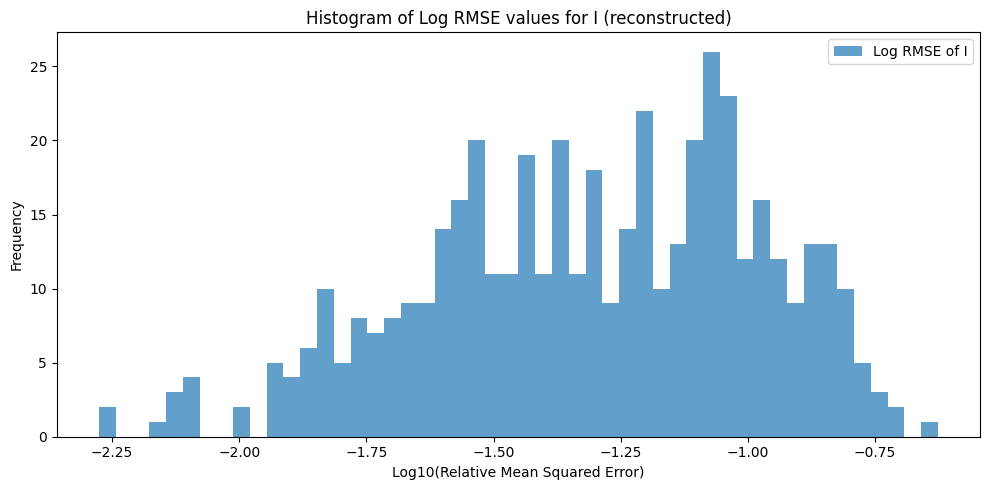

In [40]:
# Ensure phi is broadcastable to shape (num_samples, 601)
phi_expanded = data_p_experimental_nondimensional[:, 6][:, np.newaxis]  # shape: (num_samples, 1)

# Calculate I_pred using predictions_h_calculated and predictions_f_calculated
I_0_pred = 1/calculate_I(predictions_h_calculated[:,0].reshape(phi_expanded.shape), predictions_f_calculated[:,0].reshape(phi_expanded.shape), phi=phi_expanded)
I_pred = calculate_I(predictions_h_calculated, predictions_f_calculated, phi=phi_expanded, I_0=I_0_pred)

datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'a')
with datastore as hf:
    if "predictions_I_enhanced_pca_experimental" in hf:
        del hf["predictions_I_enhanced_pca_experimental"]
    hf.create_dataset("predictions_I_enhanced_pca_experimental", data=I_pred, compression="gzip")
    
datastore.close()

# Compute relative MSE for each sample
rel_rmse_I = np.sqrt(np.sum((I_pred - data_I_calculated) ** 2, axis=1) / np.sum(data_I_calculated ** 2, axis=1))

print("Experimental RMSE for I (reconstructed):", np.mean(rel_rmse_I))
# Plot histogram of log10(relative MSE)
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rel_rmse_I), bins=50, alpha=0.7, label='Log RMSE of I')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for I (reconstructed)')
plt.legend()
plt.tight_layout()

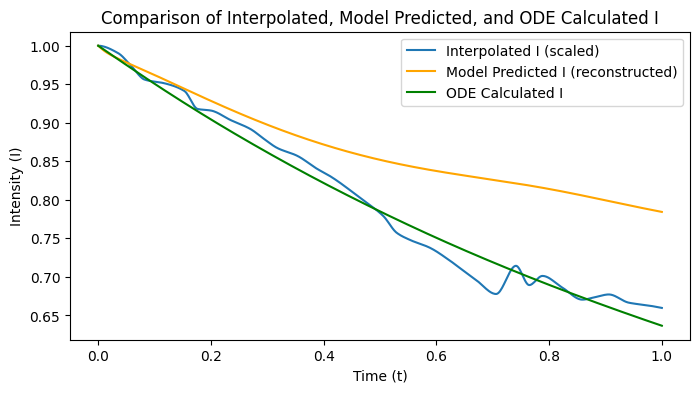

In [31]:
n = np.random.randint(0, len(I_scaled_interp))

plt.figure(figsize=(8, 4))
plt.plot(t_scaled_interp[n], I_scaled_interp[n], label='Interpolated I (scaled)')
plt.plot(t_scaled_interp[n], I_pred[n], color='orange', label='Model Predicted I (reconstructed)')
plt.plot(t_scaled_interp[n], data_I_calculated[n], color='green', label='ODE Calculated I')
plt.xlabel('Time (t)')
plt.ylabel('Intensity (I)')
plt.title('Comparison of Interpolated, Model Predicted, and ODE Calculated I')
plt.legend()
plt.show()

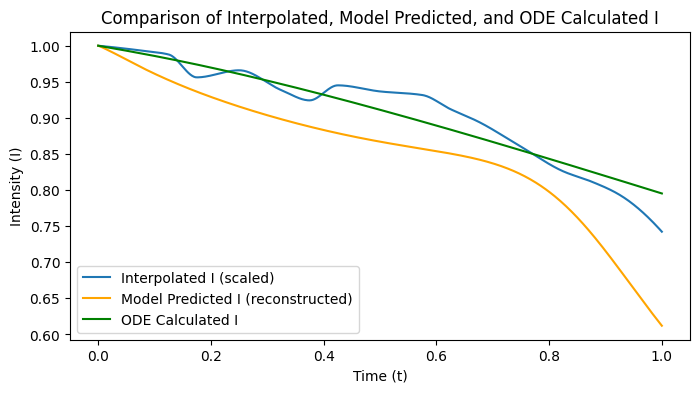

In [32]:
n = np.random.randint(0, len(I_scaled_interp))

plt.figure(figsize=(8, 4))
plt.plot(t_scaled_interp[n], I_scaled_interp[n], label='Interpolated I (scaled)')
plt.plot(t_scaled_interp[n], I_pred[n], color='orange', label='Model Predicted I (reconstructed)')
plt.plot(t_scaled_interp[n], data_I_calculated[n], color='green', label='ODE Calculated I')
plt.xlabel('Time (t)')
plt.ylabel('Intensity (I)')
plt.title('Comparison of Interpolated, Model Predicted, and ODE Calculated I')
plt.legend()
plt.show()

In [33]:
# import os

# # Path where plots will be stored
# plot_dir_h = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/h_plots"
# plot_dir_c = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/c_plots"
# plot_dir_f = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/f_plots"
# plot_dir_I = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/I_plots"
# os.makedirs(plot_dir_h, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_c, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_I, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_f, exist_ok=True)  # Create the folder if it doesn't exist

# # Loop through all 467 samples
# for idx in range(467):
#     # Get data for this sample (already loaded in your variables)
#     id = id_array[idx]
#     t = t_scaled_interp[idx]
#     I_exp = I_scaled_interp[idx]
#     h_true = data_h_calculated[idx]
#     c_true = data_c_caluculated[idx]
#     f_true = data_f_calculated[idx]
    
#     I_pred_n = I_pred[idx]
#     h_pred = predictions_h_calculated[idx]
#     c_pred = predictions_c_calculated[idx]
#     f_pred = predictions_f_calculated[idx]
    
#     I_ode = data_I_calculated[idx]
    
#     fig1, ax1 = plt.subplots()
#     ax1.plot(t, I_exp, label='Experimental I (scaled)')
#     ax1.plot(t, I_pred_n, label='Model Predicted I (reconstructed)')
#     ax1.plot(t, I_ode, color='green', label='ODE Calculated I')
#     ax1.set_title(f'I for Sample {id}')
#     ax1.set_xlabel('Time Index')
#     ax1.set_ylabel('I')
#     ax1.legend()
#     fig1.tight_layout()
#     fig1.savefig(f"{plot_dir_I}/I_{id}.png")
#     plt.close(fig1)

#     fig2, ax2 = plt.subplots()
#     ax2.plot(t, h_true, label='ODE calculated h')
#     ax2.plot(t, h_pred, label='Model Predicted h')
#     ax2.set_title(f'h for Sample {id}')
#     ax2.set_xlabel('Time Index')
#     ax2.set_ylabel('h')
#     ax2.legend()
#     fig2.tight_layout()
#     fig2.savefig(f"{plot_dir_h}/h_{id}.png")
#     plt.close(fig2)
    
#     fig3, ax3 = plt.subplots()
#     ax3.plot(t, c_true, label='ODE calculated c')
#     ax3.plot(t, c_pred, label='Model Predicted c')
#     ax3.set_title(f'c for Sample {id}')
#     ax3.set_xlabel('Time Index')
#     ax3.set_ylabel('c')
#     ax3.legend()
#     fig3.tight_layout()
#     fig3.savefig(f"{plot_dir_c}/c_{id}.png")
#     plt.close(fig3)
    
#     fig4, ax4 = plt.subplots()
#     ax4.plot(t, f_true, label='ODE calculated f')
#     ax4.plot(t, f_pred, label='Model Predicted f')
#     ax4.set_title(f'f for Sample {id}')
#     ax4.set_xlabel('Time Index')
#     ax4.set_ylabel('f')
#     ax4.legend()
#     fig4.tight_layout()
#     fig4.savefig(f"{plot_dir_f}/f_{id}.png")
#     plt.close(fig4)


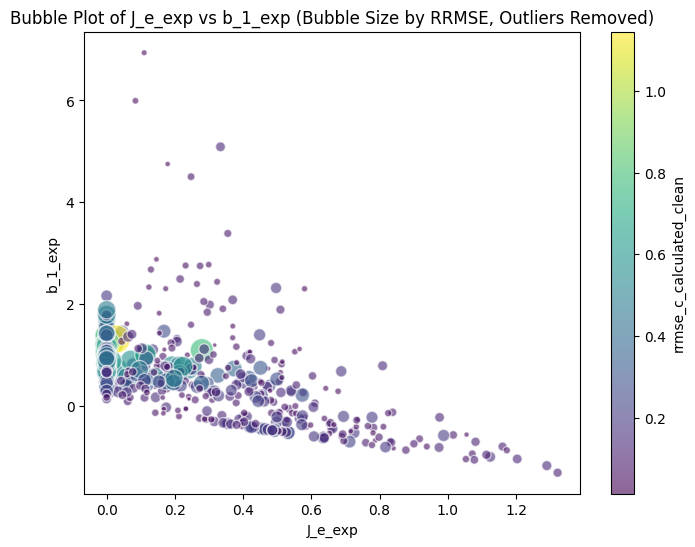

In [34]:
# Remove outliers from b_1_exp
filtered_indices_b1 = b_1_exp < np.max(b_1_exp)
# Apply the same filtering to J_e_exp and other arrays
b_1_exp_filtered = b_1_exp[filtered_indices_b1]
J_e_exp_filtered = J_e_exp[filtered_indices_b1]
# Define sizes if not already defined
sizes = (rrmse_c_calculated - np.min(rrmse_c_calculated)) / (
    np.max(rrmse_c_calculated) - np.min(rrmse_c_calculated))

sizes = sizes * 400 + 10

sizes_filtered = sizes[filtered_indices_b1]
rrmse_c_calculated_clean_filtered = rrmse_c_calculated[filtered_indices_b1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    J_e_exp_filtered,
    b_1_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_clean_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_clean')
plt.xlabel('J_e_exp')
plt.ylabel('b_1_exp')
plt.title('Bubble Plot of J_e_exp vs b_1_exp (Bubble Size by RRMSE, Outliers Removed)')
plt.show()


In [35]:
# Remove outliers from b_1_exp
filtered_indices_b2 = b_2_exp < np.max(b_2_exp)
# filtered_indices_b2 = b_2_exp < 10

# Apply the same filtering to J_e_exp and other arrays
b_2_exp_filtered = b_2_exp[filtered_indices_b2]
J_e_exp_filtered = J_e_exp[filtered_indices_b2]
sizes_filtered = sizes[filtered_indices_b2]
rrmse_c_calculated_clean_filtered = rrmse_c_calculated_clean[filtered_indices_b2]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    J_e_exp_filtered,
    b_2_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_clean_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_clean')
plt.xlabel('J_e_exp')
plt.ylabel('b_2_exp')
plt.title('Bubble Plot of J_e_exp vs b_2_exp (Bubble Size by RRMSE, Outliers Removed)')
plt.show()


NameError: name 'rrmse_c_calculated_clean' is not defined

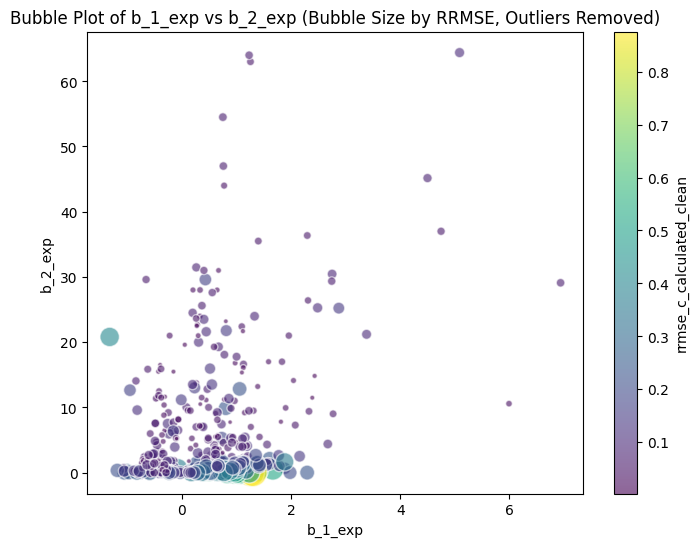

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    b_1_exp_filtered,
    b_2_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_clean_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_clean')
plt.xlabel('b_1_exp')
plt.ylabel('b_2_exp')
plt.title('Bubble Plot of b_1_exp vs b_2_exp (Bubble Size by RRMSE, Outliers Removed)')
plt.show()

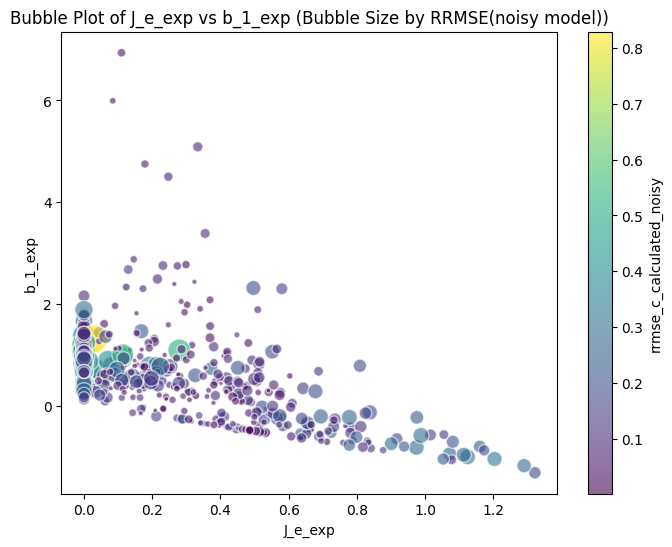

In [ ]:
# Remove outliers from b_1_exp
filtered_indices_b1 = b_1_exp < np.max(b_1_exp)
# Apply the same filtering to J_e_exp and other arrays
b_1_exp_filtered = b_1_exp[filtered_indices_b1]
J_e_exp_filtered = J_e_exp[filtered_indices_b1]
# Define sizes if not already defined
sizes = (rrmse_c_calculated_clean - np.min(rrmse_c_calculated_clean)) / (
    np.max(rrmse_c_calculated_clean) - np.min(rrmse_c_calculated_clean))

sizes = sizes * 400 + 10

sizes_filtered = sizes[filtered_indices_b1]
rrmse_c_calculated_noisy_filtered = rrmse_c_calculated_noisy[filtered_indices_b1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    J_e_exp_filtered,
    b_1_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_noisy_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_noisy')
plt.xlabel('J_e_exp')
plt.ylabel('b_1_exp')
plt.title('Bubble Plot of J_e_exp vs b_1_exp (Bubble Size by RRMSE(noisy model))')
plt.show()


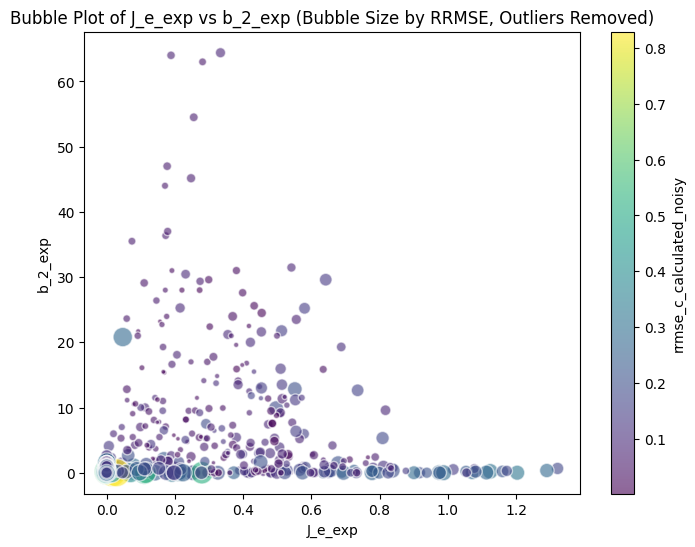

In [ ]:
# Remove outliers from b_1_exp
filtered_indices_b2 = b_2_exp < np.max(b_2_exp)

# Apply the same filtering to J_e_exp and other arrays
b_2_exp_filtered = b_2_exp[filtered_indices_b2]
J_e_exp_filtered = J_e_exp[filtered_indices_b2]
sizes_filtered = sizes[filtered_indices_b2]
rrmse_c_calculated_noisy_filtered = rrmse_c_calculated_noisy[filtered_indices_b2]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    J_e_exp_filtered,
    b_2_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_noisy_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_noisy')
plt.xlabel('J_e_exp')
plt.ylabel('b_2_exp')
plt.title('Bubble Plot of J_e_exp vs b_2_exp (Bubble Size by RRMSE, Outliers Removed)')
plt.show()


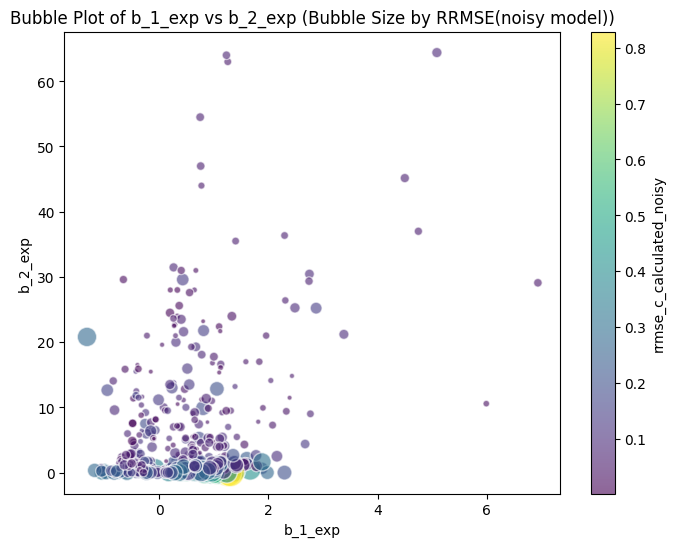

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    b_1_exp_filtered,
    b_2_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_noisy_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_noisy')
plt.xlabel('b_1_exp')
plt.ylabel('b_2_exp')
plt.title('Bubble Plot of b_1_exp vs b_2_exp (Bubble Size by RRMSE(noisy model))')
plt.show()